In [7]:
import re

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.ps_dare.paths import solve_path

PREDICTIONS_DIR = solve_path("data/weekly/predictions")
PREDICTION_DATASETS = ("general_giustiniani", "general_pediatrico", "general_osa")
PREDICTION_FILE_PATTERN = re.compile(r"_(\d{8}_\d{6})\.csv$")


# def available_prediction_runs(dataset):
#     runs = set()
#     for path in (PREDICTIONS_DIR / dataset).glob("*.csv"):
#         match = PREDICTION_FILE_PATTERN.search(path.name)
#         if match:
#             runs.add(match.group(1))
#     return runs


# def load_predictions(dataset, run):
#     paths = sorted((PREDICTIONS_DIR / dataset).glob(f"*_{run}.csv"))
#     if not paths:
#         raise FileNotFoundError(f"No predictions found for {dataset!r} in run {run}")
#     frame = pd.concat((pd.read_csv(path) for path in paths), ignore_index=True)
#     # Figure 1 uses the selected no-driver model, not weather or forced-order runs.
#     return frame.loc[frame["driver_kind"].eq("none")].copy()


# common_runs = set.intersection(
#     *(available_prediction_runs(dataset) for dataset in PREDICTION_DATASETS)
# )
# if not common_runs:
#     raise FileNotFoundError("No prediction run contains all Figure 1 datasets")
# prediction_run = max(common_runs)

# df_giustiniani, df_pediatrico, df_osa = (
#     load_predictions(dataset, prediction_run) for dataset in PREDICTION_DATASETS
# )
# print(f"Loaded prediction run: {prediction_run}")

df_giustiniani = pd.read_csv(
    PREDICTIONS_DIR
    # / "general_giustiniani/general_giustiniani_none_weekly_lag_0_model_001_20260915_163546.csv"
    / "general_giustiniani/general_giustiniani_none_weekly_lag_0_model_001_20260915_163546.csv"
)
df_pediatrico = pd.read_csv(
    PREDICTIONS_DIR
    # / "general_pediatrico/general_pediatrico_none_weekly_lag_0_model_002_20260915_163546.csv"
    / "general_pediatrico/general_pediatrico_none_weekly_lag_0_model_002_20260915_163546.csv"
)
df_osa = pd.read_csv(
    PREDICTIONS_DIR
    # / "general_osa/general_osa_none_weekly_lag_0_model_003_20260915_163546.csv"
    / "general_osa/general_osa_none_weekly_lag_0_model_003_20260915_163546.csv"
)

df_giustiniani_baseline = pd.read_csv(
    PREDICTIONS_DIR
    / "general_giustiniani/general_giustiniani_baseline_weekly_model_001_20260918_152019.csv"
)
df_pediatrico_baseline = pd.read_csv(
    PREDICTIONS_DIR
    / "general_pediatrico/general_pediatrico_baseline_weekly_model_002_20260918_152019.csv"
)
df_osa_baseline = pd.read_csv(
    PREDICTIONS_DIR
    / "general_osa/general_osa_baseline_weekly_model_003_20260918_152019.csv"
)

In [8]:
baseline_osa = "/Users/tommasobertola/Git/ps-dare-paper-2/data/weekly/metrics/general_osa/general_osa_baseline_weekly_model_003_20260918_152019.csv"
baseline_pediatrico = "/Users/tommasobertola/Git/ps-dare-paper-2/data/weekly/metrics/general_pediatrico/general_pediatrico_baseline_weekly_model_002_20260918_152019.csv"
baseline_giustiniani = "/Users/tommasobertola/Git/ps-dare-paper-2/data/weekly/metrics/general_giustiniani/general_giustiniani_baseline_weekly_model_001_20260918_152019.csv"

baseline_osa_predictions='/Users/tommasobertola/Git/ps-dare-paper-2/data/weekly/predictions/general_osa/general_osa_baseline_weekly_model_003_20260918_152019.csv'
baseline_giustiniani_predictions='/Users/tommasobertola/Git/ps-dare-paper-2/data/weekly/predictions/general_giustiniani/general_giustiniani_baseline_weekly_model_001_20260918_152019.csv'
baseline_pediatrico_predictions='/Users/tommasobertola/Git/ps-dare-paper-2/data/weekly/predictions/general_pediatrico/general_pediatrico_baseline_weekly_model_002_20260918_152019.csv'

In [9]:
date_columns = ["date", "date_start_training", "date_end_training", "date_end_testing"]
for df in (df_giustiniani, df_pediatrico, df_osa):
    df[date_columns] = df[date_columns].apply(pd.to_datetime)

In [10]:
datasets = [
    ("Giustiniani", df_giustiniani),
    ("Pediatrico", df_pediatrico),
    ("Sant'Antonio", df_osa),
]

model_metrics = []
for model_name, df in datasets:
    test = df.loc[df["phase"].eq("testing"), ["n_accesses", "prediction"]].dropna()
    absolute_errors = (test["prediction"] - test["n_accesses"]).abs()
    nonzero_actuals = test["n_accesses"].ne(0)
    actual_direction = np.sign(test["n_accesses"].diff())
    predicted_direction = np.sign(test["prediction"].diff())
    directional_accuracy = actual_direction.iloc[1:].eq(predicted_direction.iloc[1:]).mean() * 100
    model_metrics.append(
        {
            "Model": model_name,
            "MAE": absolute_errors.mean(),
            "AE (total)": absolute_errors.sum(),
            "MAPE (%)": (absolute_errors[nonzero_actuals] / test.loc[nonzero_actuals, "n_accesses"].abs()).mean() * 100,
            "Directional accuracy (%)": directional_accuracy,
            "AIC (training)": df["training_aic"].iloc[0],
        }
    )

model_metrics = pd.DataFrame(model_metrics).set_index("Model")
model_metrics.round(2).to_csv("graphs/fig1_model_metrics.csv")

In [11]:
baseline_datasets = [
    ("Giustiniani", df_giustiniani_baseline),
    ("Pediatrico", df_pediatrico_baseline),
    ("Sant'Antonio", df_osa_baseline),
]

baseline_metrics = []
for model_name, df in baseline_datasets:
    test = df.loc[df["phase"].eq("testing"), ["n_accesses", "prediction"]].dropna()
    absolute_errors = (test["prediction"] - test["n_accesses"]).abs()
    nonzero_actuals = test["n_accesses"].ne(0)
    actual_direction = np.sign(test["n_accesses"].diff())
    predicted_direction = np.sign(test["prediction"].diff())
    directional_accuracy = actual_direction.iloc[1:].eq(predicted_direction.iloc[1:]).mean() * 100
    baseline_metrics.append(
        {
            "Model": model_name,
            "MAE": absolute_errors.mean(),
            "MAPE (%)": (absolute_errors[nonzero_actuals] / test.loc[nonzero_actuals, "n_accesses"].abs()).mean() * 100,
            "Directional accuracy (%)": directional_accuracy,
            "AE (total)": absolute_errors.sum(),
        }
    )

baseline_metrics = pd.DataFrame(baseline_metrics).set_index("Model")
baseline_metrics.round(2).to_csv("graphs/fig1_baseline_metrics.csv")

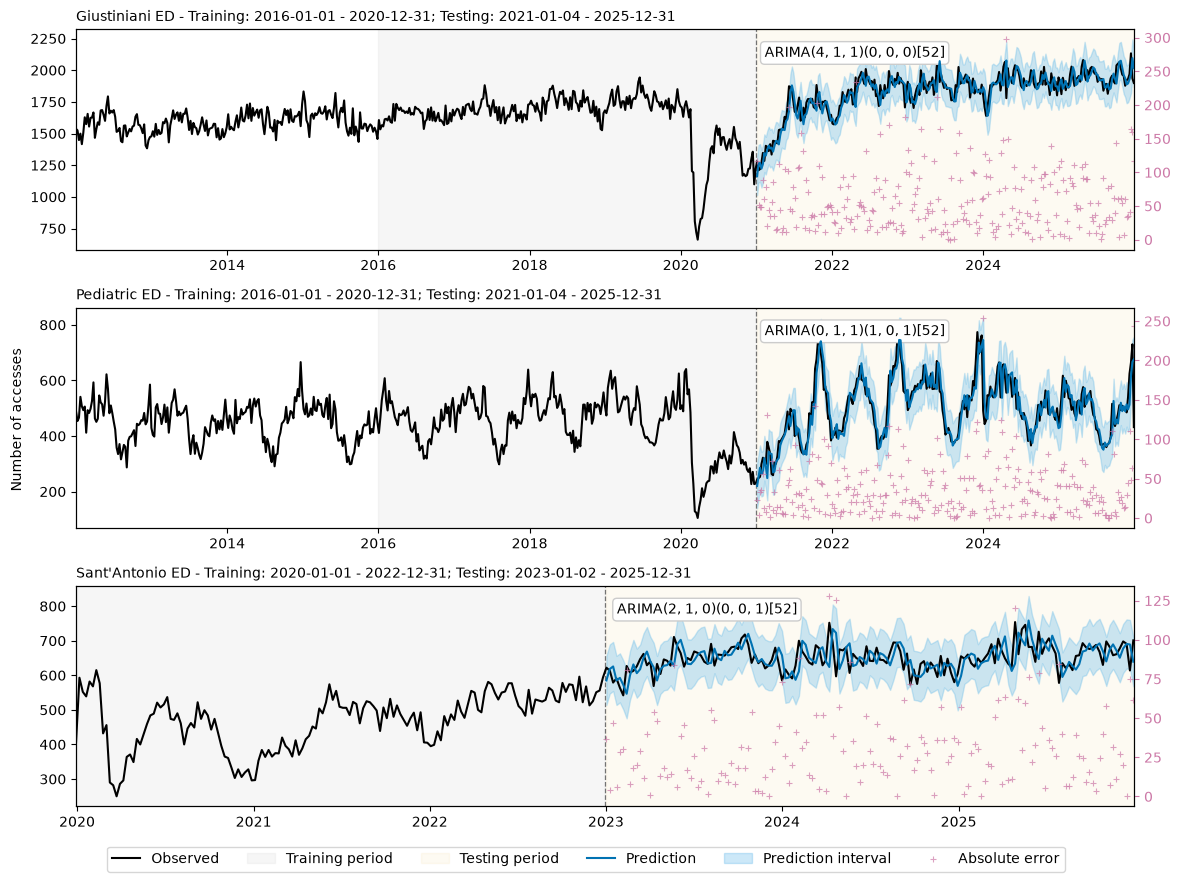

In [12]:
plot_font_size = 10
plt.rcParams.update(
    {
        "font.size": plot_font_size,
        "axes.titlesize": plot_font_size,
        "axes.labelsize": plot_font_size,
        "xtick.labelsize": plot_font_size,
        "ytick.labelsize": plot_font_size,
        "legend.fontsize": plot_font_size,
        "figure.titlesize": plot_font_size,
        "figure.labelsize": plot_font_size,
    }
)

datasets = [
    ("Giustiniani", df_giustiniani),
    ("Pediatric", df_pediatrico),
    ("Sant'Antonio", df_osa),
]

# High-contrast, colorblind-friendly palette; observed values remain black.
prediction_color = "#0072B2"
prediction_interval_color = "#56B4E9"
testing_period_color = "#E69F00"
absolute_error_color = "#CC79A7"

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 8.5),
    sharex=False,
)

error_axes = []

for ax, (title, df) in zip(axes, datasets):
    training_start = df["date_start_training"].iloc[0]
    training_end = df["date_end_training"].iloc[0]
    testing_start = df.loc[df["phase"] == "testing", "date"].min()
    testing_end = df["date_end_testing"].iloc[0]
    order = tuple(int(df[column].iloc[0]) for column in ("p", "d", "q"))
    seasonal_order = tuple(int(df[column].iloc[0]) for column in ("P", "D", "Q"))
    observed = df.loc[
        df["phase"].isin(["before_training", "training", "testing"]),
        ["date", "n_accesses"],
    ].dropna(subset=["n_accesses"])
    test = df.loc[df["phase"] == "testing"]
    absolute_error = (test["prediction"] - test["n_accesses"]).abs()

    ax.plot(observed["date"], observed["n_accesses"], label="Observed", color="black", zorder=3)
    ax.axvspan(
        training_start,
        training_end,
        color="lightgray",
        alpha=0.2,
        label="Training period",
        zorder=0,
    )
    ax.axvspan(
        testing_start,
        testing_end,
        color=testing_period_color,
        alpha=0.05,
        label="Testing period",
        zorder=0,
    )
    ax.axvline(training_end, color="0.45", linestyle="--", linewidth=0.9)

    ax.plot(
        test["date"],
        test["prediction"],
        label="Prediction",
        color=prediction_color,
        zorder=4,
    )
    ax.fill_between(
        test["date"],
        test["prediction_lower_bound"],
        test["prediction_upper_bound"],
        color=prediction_interval_color,
        alpha=0.3,
        label="Prediction interval",
        zorder=2,
    )
    ax_error = ax.twinx()
    ax_error.scatter(
        test["date"],
        absolute_error,
        marker="+",
        s=20,
        linewidths=0.8,
        color=absolute_error_color,
        alpha=0.7,
        label="Absolute error",
    )

    ax_error.tick_params(axis="y", colors=absolute_error_color)
    error_axes.append(ax_error)
    ax.set_xlim(observed["date"].min(), testing_end)
    ax.set_title(
        rf"{title} ED - "
        f"Training: {training_start:%Y-%m-%d} - {training_end:%Y-%m-%d}; "
        f"Testing: {testing_start:%Y-%m-%d} - {testing_end:%Y-%m-%d}",
        loc="left",
        fontsize=plot_font_size,
    )

    # ax.set_ylabel(, fontdict={"fontsize": 11})
    locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.tick_params(axis="x", labelrotation=0)

    model_label_x = testing_start + 0.02 * (testing_end - testing_start)
    ax.text(
        model_label_x,
        0.86,
        f"ARIMA{order}{seasonal_order}[52]",
        transform=ax.get_xaxis_transform(),
        ha="left",
        va="bottom",
        # fontsize=10,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.8"},
    )
fig.supylabel("Number of accesses")
plot_handles, plot_labels = axes[0].get_legend_handles_labels()
error_handles, error_labels = error_axes[0].get_legend_handles_labels()
handles = plot_handles + error_handles
labels = plot_labels + error_labels
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=6,
    fontsize=plot_font_size,
)
fig.subplots_adjust(
    left=0.1, right=0.92, bottom=0.12, top=0.96, hspace=0.28
)
plt.tight_layout()
plt.savefig(
    solve_path("graphs/fig1.pdf"),
    bbox_inches="tight",
)